<a href="https://colab.research.google.com/github/sargyri/Drop_Lev/blob/master/Applications/PNIPAM%20/Machine_learning/ML_transfer_learning_on_microgels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2018 The TensorFlow Authors.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [ ]:
#@title MIT License
#
# Copyright (c) 2017 François Chollet
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# Lev Droplet

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/keras/basic_regression"><img src="https://www.tensorflow.org/images/tf_logo_32px.png" />View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/r2.0rc/site/en/tutorials/keras/basic_regression.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/r2.0rc/site/en/tutorials/keras/basic_regression.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

### Applying the training neural netowrk on new data

In [ ]:
import os
import re
import glob
import pathlib

import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

import time

import numpy as np
import pandas as pd

from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
# from scipy.signal import  gaussian
from scipy.ndimage import filters
from scipy import optimize
from scipy.stats import linregress
import scipy as sp
import scipy.interpolate
# from scipy.integrate import trapz



import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow.keras.backend as kb
from tensorflow.keras import Model

from scipy.stats import gaussian_kde
from matplotlib.colors import Normalize
from matplotlib import cm
import io

from random import randint
from sklearn.utils import shuffle
from google.colab import drive
from numpy.random import seed
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping


def min_max_norm(x):
  return (x-stats['min'])/(stats['max']-stats['min'])


def MinMaxTransformTrain(dataset_train, points):

  max_rho=[]
  min_rho=[]
  for i in range(len(dataset_train)):
    max_rho.append(max(dataset_train.iloc[i, 0:points].values))
    min_rho.append(min(dataset_train.iloc[i, 0:points].values))

  # Change the range of rho from 0 to 1
  OldMax= max(max_rho)
  OldMin=min(min_rho)

  NewValues_rho={}

  OldRange = abs(OldMax - OldMin)
  for i in range(len(dataset_train)):
    if (OldRange == 0):
        NewValue = OldMin
        NewValues_rho[i]=(NewValue)
    else:
        NewValue = (dataset_train.iloc[i, 0:points] - OldMin)/(OldMax-OldMin)
        NewValues_rho[i]=NewValue

  df_rho=pd.DataFrame.from_dict(NewValues_rho).T

  return df_rho


def MinMaxTransformTest(dataset_test, dataset_train, points):

  max_rho=[]
  min_rho=[]
  for i in range(len(dataset_train)):
    max_rho.append(max(dataset_train.iloc[i, 0:points].values))
    min_rho.append(min(dataset_train.iloc[i, 0:points].values))

  # Change the range of rho from 0 to 1

  OldMax= max(max_rho)
  OldMin=min(min_rho)

  NewValues_rho={}

  OldRange = abs(OldMax - OldMin)
  for i in range(len(dataset_test)):
    if (OldRange == 0):
        NewValue = OldMin
        NewValues_rho[i]=NewValue
    else:
        NewValue = (dataset_test.iloc[i, 0:points] - OldMin)/(OldMax-OldMin)
        NewValues_rho[i]=NewValue

  df_rho=pd.DataFrame.from_dict(NewValues_rho).T


  return df_rho


def density_scatter(x, y, title=None, label=None, colours='magma_r', lim1=10, lim2=80, eq_sq=True, figsize=(8,8)):
  # Calculate the point density
  x=np.asarray(x)
  y=np.asarray(y)
  xy = np.vstack([x, y])
  z = gaussian_kde(xy)(xy)
  # Sort the points by density, so that the densest points are plotted last
  idx = z.argsort()
  x, y, z = x[idx], y[idx], z[idx]

  fig, ax = plt.subplots(figsize=figsize)
  ax.set_facecolor('whitesmoke')
  if title!=None:
    plt.title(title)
  im=ax.scatter(x, y, label=label, c=z, s=50, cmap=colours)
  plt.xlabel('True Values of ST (mN/m)')
  plt.ylabel('Predictions of ST (mN/m)')
  if eq_sq==True:
    plt.axis('equal')
    plt.axis('square')
  # plt.xlim([lim1, lim2])
  # plt.ylim([lim1, lim2])
  norm = Normalize(vmin = np.min(z), vmax = np.max(z))
  cbar = fig.colorbar(cm.ScalarMappable(norm = norm, cmap=colours), ax=ax)
  cbar.ax.set_ylabel('Density')

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]



def pol2cart(rho, phi):
    ''' Function that converts 2-dimentional
  polar coordinates to cartesian coordinates'''
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    return(x, y)


def calc_surface_area_axisymmetric(x, y, smoothing_sigma=2):
    """
    Calculate surface area of axisymmetric drop given Cartesian contour points (x,y).

    Parameters:
    -----------
    x, y : arrays of Cartesian coordinates of the drop contour (must cover full profile)
    smoothing_sigma : float, standard deviation for Gaussian smoothing of radius profile

    Returns:
    --------
    Surface area in same units squared as x,y

    """
    # Convert contour to radius vs vertical coordinate (assuming symmetry about x=0)
    # Sort points by y
    sorted_indices = np.argsort(y)
    y_sorted = y.iloc[sorted_indices]
    x_sorted = x.iloc[sorted_indices]

    # Calculate radius as abs(x) since axisymmetric
    r = np.abs(x_sorted)

    # Remove duplicate y values (keep first)
    _, unique_indices = np.unique(y_sorted, return_index=True)
    y_unique = y_sorted.iloc[unique_indices]
    r_unique = r.iloc[unique_indices]

    # Smooth radius to reduce noise / oscillations
    r_smooth = gaussian_filter1d(r_unique, sigma=smoothing_sigma)

    # Linear interpolation of radius vs y
    interp_func = interp1d(y_unique, r_smooth, kind='linear', fill_value='extrapolate')

    # Fine sampling of y for integration
    y_fine = np.linspace(min(y_unique), max(y_unique), 1000)
    r_fine = interp_func(y_fine)

    # Calculate numerical derivative dr/dy safely
    dr_dy = np.gradient(r_fine, y_fine)

    # Surface area formula for revolution about y-axis:
    integrand = 2 * np.pi * r_fine * np.sqrt(1 + dr_dy**2)

    # Numerical integration using trapezoidal rule
    surface_area = np.trapezoid(integrand, y_fine)

    return surface_area


### Connect to google drive

#### **If** the required files are on google drive, run this code to connect to the google drive.

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


### Import and visualize training dataset for normalization

#### **First**: Upload the training dataset, test dataset and the file containing the trained neural network, to the files folder or define the path to those files in google drive.  

,rho_0,rho_1,rho_2,rho_3,rho_4,rho_5,rho_6,rho_7,rho_8,rho_9,...,phi_173,phi_174,volume,Aspect_Ratio,volt,current,centred_z,surfactant_conc,ST,surf_number
46690,0.817458,0.819281,0.818349,0.816758,0.815800,0.814156,0.813548,0.810016,0.807470,0.805922,...,3.098966,3.135,1.951601,1.165761,6.68,0.277,-0.156383,1.405932,38.186800,1.0
46691,0.734421,0.735177,0.733054,0.731874,0.731637,0.729771,0.730118,0.728796,0.724406,0.722571,...,3.098966,3.135,1.417612,1.167173,6.77,0.281,-0.111630,0.607334,29.319754,2.0
46692,0.676648,0.678312,0.677033,0.676624,0.677098,0.674553,0.672849,0.671993,0.670308,0.668801,...,3.098966,3.135,1.128066,1.145161,7.22,0.296,-0.103432,0.422297,29.731824,2.0
46693,0.762581,0.764566,0.763723,0.763867,0.761130,0.759349,0.758532,0.756957,0.755439,0.753855,...,3.098966,3.135,1.607457,1.146132,6.60,0.276,-0.118464,0.229848,34.512111,2.0
46694,0.716716,0.715276,0.715206,0.713379,0.714116,0.711889,0.708105,0.706136,0.702770,0.700117,...,3.098966,3.135,1.247519,1.224756,7.68,0.304,0.049059,0.296165,31.692066,2.0


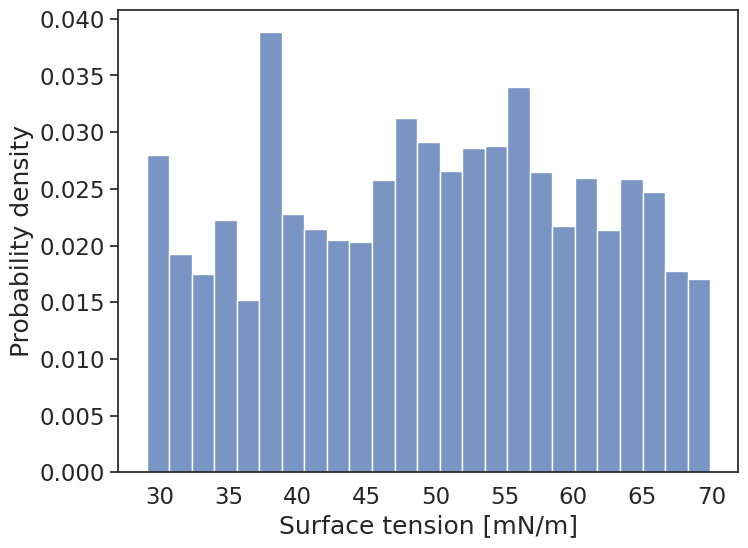

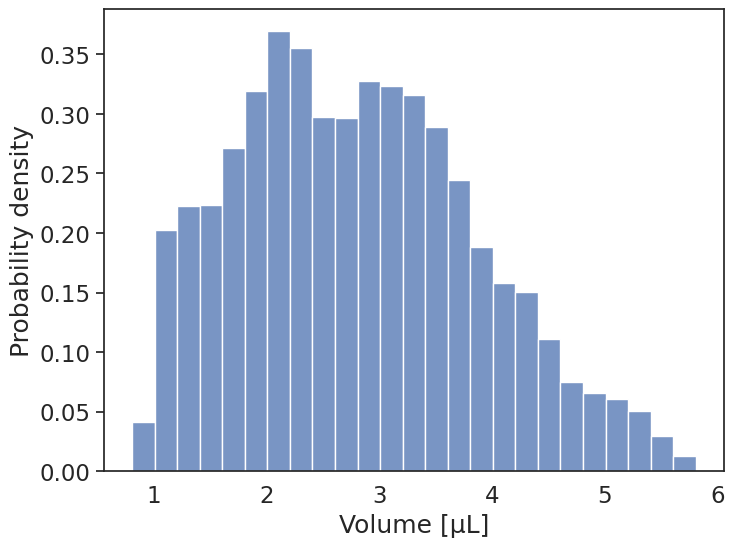

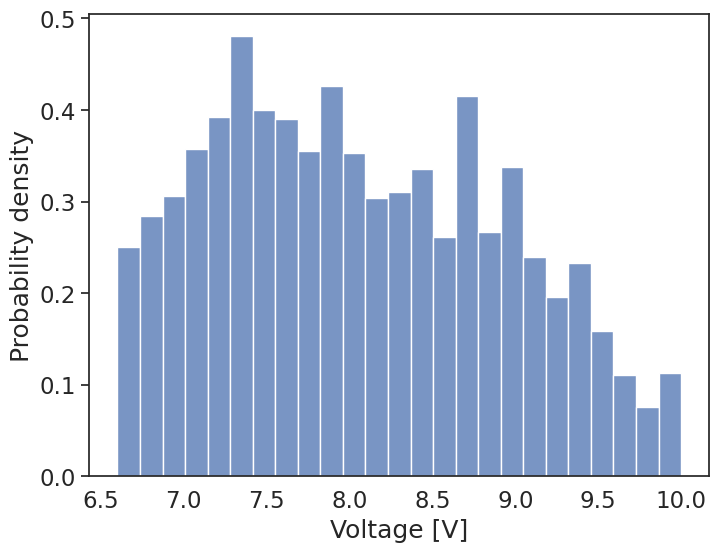

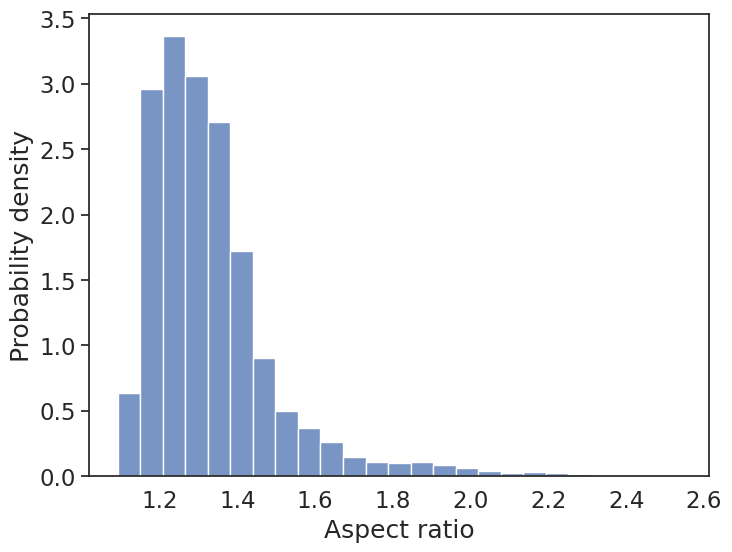

In [ ]:
sns.set_theme(style='ticks', font_scale=1.5)


path_files=str('/content/drive/My Drive/Atieh_levitation/')
# os.chdir(path_files)
# training_dataset=pd.read_csv(str(path_files+'training_dataset_for_normalization.csv'), sep="\t", header=None)

training_dataset=pd.read_csv(str(path_files+'training_dataset_pre_norm.csv'),  header=0, sep=';')
training_dataset.pop('Unnamed: 0')



### Plot data distribution
plt.figure(figsize=(8,6))
plt.ylabel('Probability density')
sns.histplot(training_dataset.loc[:, 'ST'], kde=False, bins=25, stat="density")
plt.xlabel('Surface tension [mN/m]')
plt.tick_params(bottom = False)

plt.figure(figsize=(8,6))
plt.ylabel('Probability density')
sns.histplot(training_dataset.loc[:, 'volume'], kde=False, bins=25, stat="density")
plt.xlabel('Volume [μL]')
plt.tick_params(bottom = False)


plt.figure(figsize=(8,6))
plt.ylabel('Probability density')
sns.histplot(training_dataset.loc[:, 'volt'], kde=False, bins=25, stat="density")
plt.xlabel('Voltage [V]')
plt.tick_params(bottom = False)



plt.figure(figsize=(8,6))
plt.ylabel('Probability density')
sns.histplot(training_dataset.loc[:, 'Aspect_Ratio'], kde=False, bins=25, stat="density")
plt.xlabel('Aspect ratio')
plt.tick_params(bottom = False)

training_dataset.dropna(axis=0)

### Print the last 5 rows of the training dataset
training_dataset.tail()





In [ ]:
### Remove the columns we don't use, but save the values as variables
volume_train=training_dataset.pop('volume')
Aspect_Ratio_train=training_dataset.pop('Aspect_Ratio')
surf_conc_train=training_dataset.pop('surfactant_conc')
surf_number_train=training_dataset.pop('surf_number')

### Print the statistics of the training dataset
points=175
if training_dataset.shape[1]>2*points:
  stats = training_dataset.iloc[:, 2*points:].describe()
else:
  stats = training_dataset.iloc[:, points:].describe()


stats = stats.transpose()
stats

,count,mean,std,min,25%,50%,75%,max
volt,46695.0,8.063710,0.857414,6.600000,7.340000,7.970000,8.750000,10.000000
current,46695.0,0.312764,0.019648,0.272000,0.296000,0.312000,0.329000,0.366000
centred_z,46695.0,0.001997,0.094150,-0.323581,-0.069027,0.020304,0.080019,0.244943
ST,46695.0,49.504606,11.279460,29.024210,39.751155,49.820528,58.573276,69.925068


### Normalize the training dataset

In [ ]:

new_df_train=MinMaxTransformTrain(dataset_train=training_dataset, points=175)
new_df_train.tail()


if training_dataset.shape[1]>2*points:
  normed_train_data_rest = min_max_norm(training_dataset.iloc[:, 2*points:])

else:
  normed_train_data_rest = min_max_norm(training_dataset.iloc[:, points:])


normed_train_data = new_df_train.copy()

normed_train_data['centred_z'] = normed_train_data_rest.centred_z
normed_train_data['volt'] = normed_train_data_rest.volt
normed_train_data['current'] = normed_train_data_rest.current
normed_train_data['ST'] = normed_train_data_rest.ST


normed_train_data.tail()



,rho_0,rho_1,rho_2,rho_3,rho_4,rho_5,rho_6,rho_7,rho_8,rho_9,...,rho_169,rho_170,rho_171,rho_172,rho_173,rho_174,centred_z,volt,current,ST
46690,0.426971,0.429182,0.428052,0.426121,0.424959,0.422964,0.422226,0.417940,0.414851,0.412972,...,0.418530,0.423149,0.424376,0.426875,0.426036,0.426485,0.294091,0.023529,0.053191,0.224020
46691,0.326212,0.327130,0.324554,0.323121,0.322835,0.320570,0.320992,0.319387,0.314060,0.311834,...,0.317665,0.321776,0.322317,0.324001,0.326828,0.326163,0.372809,0.050000,0.095745,0.007226
46692,0.256110,0.258129,0.256577,0.256080,0.256656,0.253568,0.251500,0.250461,0.248417,0.246588,...,0.249586,0.250541,0.252546,0.255598,0.255086,0.255643,0.387228,0.182353,0.255319,0.017301
46693,0.360382,0.362791,0.361767,0.361943,0.358621,0.356460,0.355469,0.353558,0.351716,0.349794,...,0.354084,0.354698,0.356498,0.359485,0.359045,0.359804,0.360788,0.000000,0.042553,0.134176
46694,0.304729,0.302982,0.302896,0.300680,0.301574,0.298872,0.294281,0.291891,0.287807,0.284587,...,0.293792,0.299228,0.301109,0.304101,0.303596,0.304220,0.655452,0.317647,0.340426,0.065227


### Import test datatset

In [ ]:
### Import test dataset
folder = str('20250528')
filename = str('MG1_0.010wtp_Vi_8.0_Vf_11.0_rate_0.500Hz_2.csv') #MG10_0.100wtp_V_ct_8.00_3.csv      water_0.000wtp_V_ct_8.00_3
test_dataset=pd.read_csv(str(path_files+folder+'/'+filename), header=0, sep='\t')
test_dataset.tail()

,data_rho1,data_rho2,data_rho3,data_rho4,data_rho5,data_rho6,data_rho7,data_rho8,data_rho9,data_rho10,...,data_rho175,time,volt,current,Volume,Aspect_Ratio,Integr_Surface_Area,centred_z,conc,content
135,0.958408,0.956117,0.955060,0.951880,0.946534,0.942319,0.934480,0.927172,0.917956,0.909222,...,0.958390,143.322428,10.0,0.314,2.426923,0.653913,6.863636,-1.741667,NaN,0.010898
136,0.973411,0.974481,0.973473,0.967010,0.963341,0.956420,0.947952,0.938940,0.925863,0.914445,...,0.973390,144.376374,9.5,0.304,2.421319,0.616041,6.990283,-1.733333,NaN,0.010923
137,0.983410,0.987824,0.986647,0.980425,0.975225,0.969294,0.960831,0.949631,0.937915,0.923663,...,0.983391,145.430357,9.0,0.292,2.427521,0.597973,6.761729,-1.705000,NaN,0.010895
138,1.001746,0.999506,0.998557,0.992183,0.987045,0.977784,0.966350,0.953927,0.940550,0.924365,...,0.999348,146.484283,8.5,0.281,2.435362,0.564060,6.940369,-1.713333,NaN,0.010860
139,1.033357,1.030940,1.026508,1.020029,1.011452,0.998730,0.984280,0.968013,0.951447,0.928847,...,1.030140,147.538388,8.0,0.270,2.422540,0.506452,7.020777,-1.705000,NaN,0.010917


### Import and visualize the new data

,data_rho1,data_rho2,data_rho3,data_rho4,data_rho5,data_rho6,data_rho7,data_rho8,data_rho9,data_rho10,...,data_rho169,data_rho170,data_rho171,data_rho172,data_rho173,data_rho174,data_rho175,volt,current,centred_z
135,0.958408,0.956117,0.955060,0.951880,0.946534,0.942319,0.934480,0.927172,0.917956,0.909222,...,0.921921,0.931896,0.939560,0.944991,0.951593,0.956048,0.958390,10.0,0.314,-1.741667
136,0.973411,0.974481,0.973473,0.967010,0.963341,0.956420,0.947952,0.938940,0.925863,0.914445,...,0.933856,0.943746,0.954715,0.961358,0.966631,0.971056,0.973390,9.5,0.304,-1.733333
137,0.983410,0.987824,0.986647,0.980425,0.975225,0.969294,0.960831,0.949631,0.937915,0.923663,...,0.934011,0.944752,0.954733,0.963448,0.972930,0.977736,0.983391,9.0,0.292,-1.705000
138,1.001746,0.999506,0.998557,0.992183,0.987045,0.977784,0.966350,0.953927,0.940550,0.924365,...,0.950726,0.962431,0.974832,0.983799,0.991721,0.996087,0.999348,8.5,0.281,-1.713333
139,1.033357,1.030940,1.026508,1.020029,1.011452,0.998730,0.984280,0.968013,0.951447,0.928847,...,0.969488,0.985608,0.999495,1.011149,1.020655,1.028081,1.030140,8.0,0.270,-1.705000


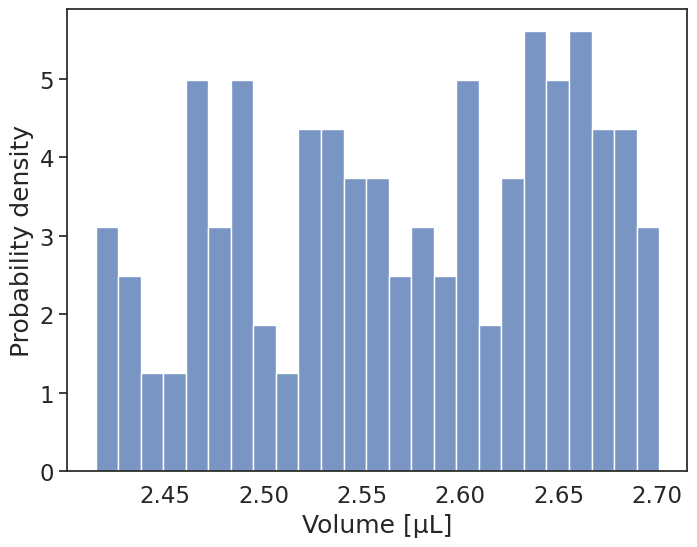

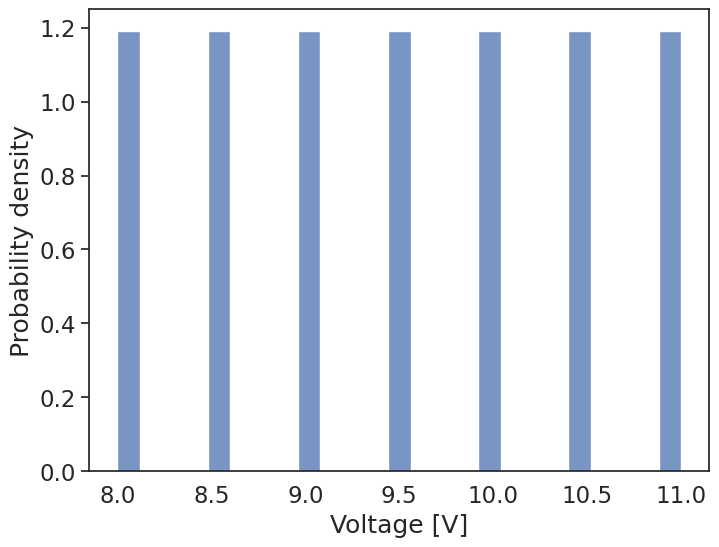

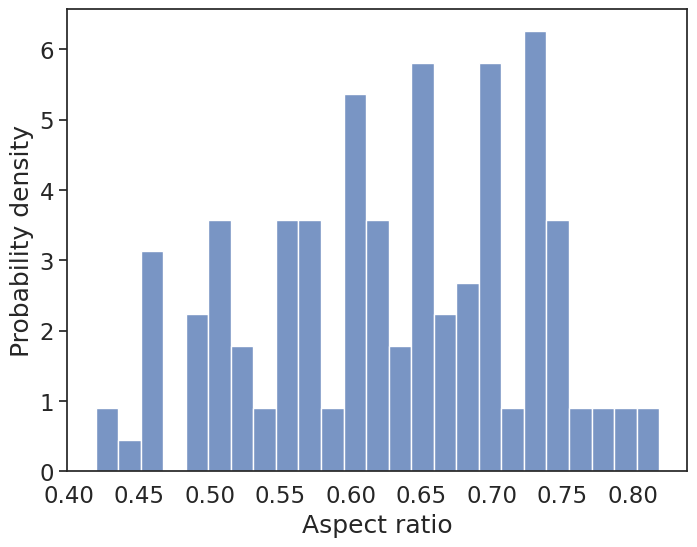

In [ ]:
### Plot data distribution

plt.figure(figsize=(8,6))
plt.ylabel('Probability density')
sns.histplot(test_dataset.loc[:, 'Volume'], kde=False, bins=25, stat="density")
plt.xlabel('Volume [μL]')
plt.tick_params(bottom = False)

plt.figure(figsize=(8,6))
plt.ylabel('Probability density')
sns.histplot(test_dataset.loc[:, 'volt'], kde=False, bins=25, stat="density")
plt.xlabel('Voltage [V]')
plt.tick_params(bottom = False)

plt.figure(figsize=(8,6))
plt.ylabel('Probability density')
sns.histplot(test_dataset.loc[:, 'Aspect_Ratio'], kde=False, bins=25, stat="density")
plt.xlabel('Aspect ratio')
plt.tick_params(bottom = False)


### Prepare dataset for predictions

Surface_Area = test_dataset.pop('Integr_Surface_Area')
Aspect_Ratio_test = test_dataset.pop('Aspect_Ratio')
volume_test = test_dataset.pop('Volume')
Time = test_dataset.pop('time')

if filename.startswith('MG'):
  concentration = test_dataset.pop('content')
  test_dataset.pop('conc')

test_dataset.tail()



Text(0.5, 0, 'Time (min)')

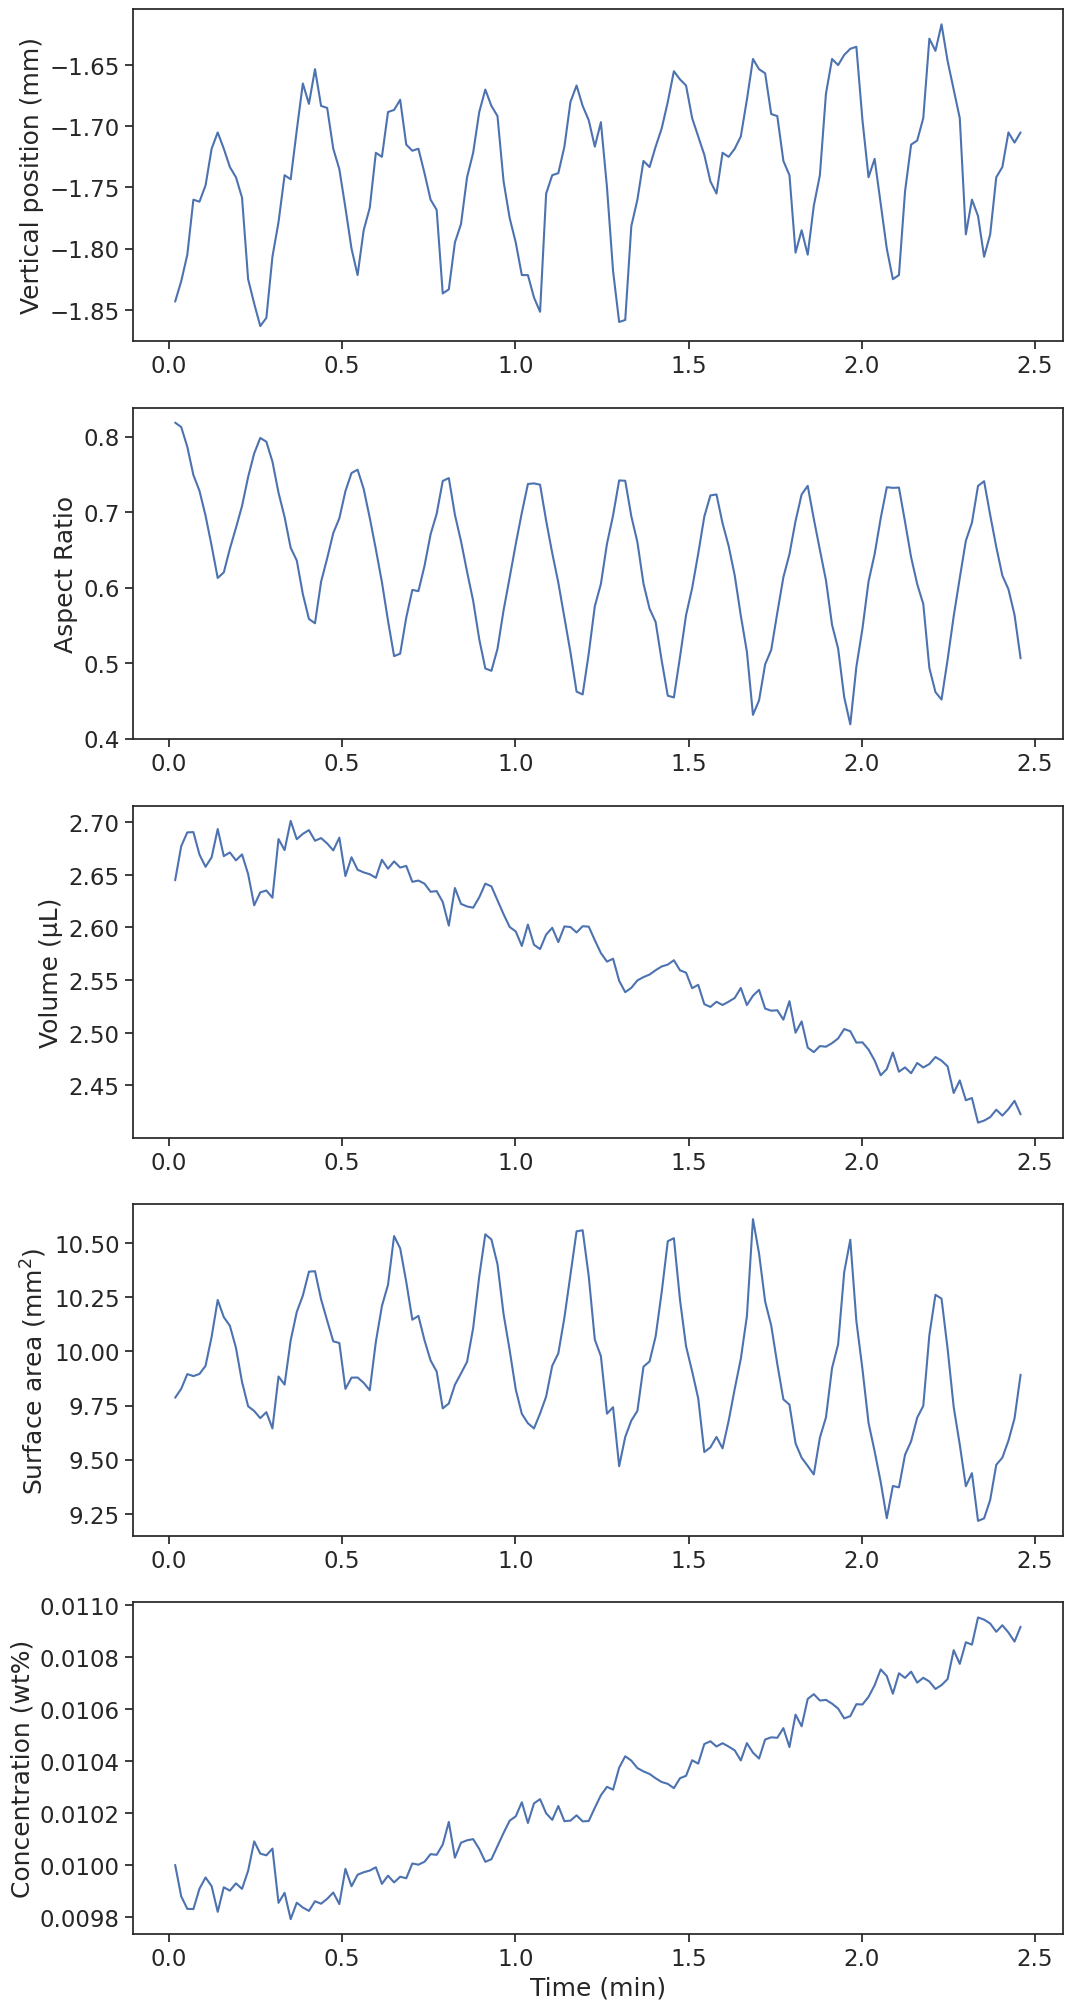

In [ ]:

fig, axs = plt.subplots(5, figsize=(12, 25))
# axs[0].plot(Time/60, ST_pred_test)
# axs[0].set_ylabel('Surface tension (mN/m)')
axs[0].plot(Time/60, test_dataset.centred_z)
axs[0].set_ylabel('Vertical position (mm)')
axs[1].plot(Time/60, Aspect_Ratio_test)
axs[1].set_ylabel('Aspect Ratio')
axs[2].plot(Time/60, volume_test)
axs[2].set_ylabel('Volume (μL)')
axs[3].plot(Time/60, Surface_Area)
axs[3].set_ylabel('Surface area (mm$^2$)')
axs[4].plot(Time/60, concentration)
axs[4].set_ylabel('Concentration (wt%)')
axs[4].set_xlabel('Time (min)')



In [ ]:
### Rename columns to the ones for the training dataset

test_dataset = test_dataset.rename(columns={'Voltage': 'volt', 'Current': 'current', 'Y_center': 'centred_z'})
#test_dataset.pop('Unnamed: 0')
test_dataset.tail()

,data_rho1,data_rho2,data_rho3,data_rho4,data_rho5,data_rho6,data_rho7,data_rho8,data_rho9,data_rho10,...,data_rho169,data_rho170,data_rho171,data_rho172,data_rho173,data_rho174,data_rho175,volt,current,centred_z
135,0.958408,0.956117,0.955060,0.951880,0.946534,0.942319,0.934480,0.927172,0.917956,0.909222,...,0.921921,0.931896,0.939560,0.944991,0.951593,0.956048,0.958390,10.0,0.314,-1.741667
136,0.973411,0.974481,0.973473,0.967010,0.963341,0.956420,0.947952,0.938940,0.925863,0.914445,...,0.933856,0.943746,0.954715,0.961358,0.966631,0.971056,0.973390,9.5,0.304,-1.733333
137,0.983410,0.987824,0.986647,0.980425,0.975225,0.969294,0.960831,0.949631,0.937915,0.923663,...,0.934011,0.944752,0.954733,0.963448,0.972930,0.977736,0.983391,9.0,0.292,-1.705000
138,1.001746,0.999506,0.998557,0.992183,0.987045,0.977784,0.966350,0.953927,0.940550,0.924365,...,0.950726,0.962431,0.974832,0.983799,0.991721,0.996087,0.999348,8.5,0.281,-1.713333
139,1.033357,1.030940,1.026508,1.020029,1.011452,0.998730,0.984280,0.968013,0.951447,0.928847,...,0.969488,0.985608,0.999495,1.011149,1.020655,1.028081,1.030140,8.0,0.270,-1.705000


In [ ]:
### Average z position of training dataset for a speicifc voltage:
# filtered_df = training_dataset.loc[training_dataset['volt'] == 8]
filtered_df = training_dataset[(training_dataset['volt'] >= 8) & (training_dataset['volt'] <= 11)]

target_avg_z = np.mean(filtered_df.centred_z)
print(target_avg_z)

0.06464680745005912


In [ ]:
### Center the Z-center

avg_z = np.average(test_dataset.centred_z)

test_dataset.centred_z = test_dataset.centred_z - avg_z + target_avg_z

print('Average z-centre: %.3f mm' %np.mean(test_dataset.centred_z))
test_dataset.tail()

Average z-centre: 0.065 mm


,data_rho1,data_rho2,data_rho3,data_rho4,data_rho5,data_rho6,data_rho7,data_rho8,data_rho9,data_rho10,...,data_rho169,data_rho170,data_rho171,data_rho172,data_rho173,data_rho174,data_rho175,volt,current,centred_z
135,0.958408,0.956117,0.955060,0.951880,0.946534,0.942319,0.934480,0.927172,0.917956,0.909222,...,0.921921,0.931896,0.939560,0.944991,0.951593,0.956048,0.958390,10.0,0.314,0.058206
136,0.973411,0.974481,0.973473,0.967010,0.963341,0.956420,0.947952,0.938940,0.925863,0.914445,...,0.933856,0.943746,0.954715,0.961358,0.966631,0.971056,0.973390,9.5,0.304,0.066540
137,0.983410,0.987824,0.986647,0.980425,0.975225,0.969294,0.960831,0.949631,0.937915,0.923663,...,0.934011,0.944752,0.954733,0.963448,0.972930,0.977736,0.983391,9.0,0.292,0.094873
138,1.001746,0.999506,0.998557,0.992183,0.987045,0.977784,0.966350,0.953927,0.940550,0.924365,...,0.950726,0.962431,0.974832,0.983799,0.991721,0.996087,0.999348,8.5,0.281,0.086540
139,1.033357,1.030940,1.026508,1.020029,1.011452,0.998730,0.984280,0.968013,0.951447,0.928847,...,0.969488,0.985608,0.999495,1.011149,1.020655,1.028081,1.030140,8.0,0.270,0.094873


### Normalize the test dataset based on the training dataset

In [ ]:
### Normalize the test dataset based on training dataset

new_df_test=MinMaxTransformTest(test_dataset, training_dataset, points=175)

# new_df_test.tail()


if test_dataset.shape[1]>2*points:
  normed_test_data_rest = min_max_norm(test_dataset.iloc[:, 2*points:])
else:
  normed_test_data_rest = min_max_norm(test_dataset.iloc[:, points:])


#Putting scalled test dataset together

normed_test_data = new_df_test.copy()

normed_test_data['centred_z'] = normed_test_data_rest.centred_z
normed_test_data['volt'] = normed_test_data_rest.volt
normed_test_data['current'] = normed_test_data_rest.current


normed_test_data.tail()

,data_rho1,data_rho2,data_rho3,data_rho4,data_rho5,data_rho6,data_rho7,data_rho8,data_rho9,data_rho10,...,data_rho169,data_rho170,data_rho171,data_rho172,data_rho173,data_rho174,data_rho175,centred_z,volt,current
135,0.598001,0.595221,0.593938,0.590079,0.583593,0.578478,0.568967,0.560099,0.548916,0.538318,...,0.553727,0.565830,0.575131,0.581720,0.589732,0.595138,0.597979,0.671541,1.000000,0.446809
136,0.616205,0.617504,0.616281,0.608438,0.603986,0.595589,0.585313,0.574378,0.558511,0.544656,...,0.568209,0.580210,0.593520,0.601580,0.607978,0.613348,0.616180,0.686199,0.852941,0.340426
137,0.628339,0.633695,0.632267,0.624717,0.618407,0.611210,0.600941,0.587350,0.573134,0.555841,...,0.568397,0.581430,0.593542,0.604116,0.615622,0.621454,0.628316,0.736036,0.705882,0.212766
138,0.650587,0.647870,0.646718,0.638984,0.632749,0.621512,0.607638,0.592564,0.576332,0.556693,...,0.588679,0.602882,0.617930,0.628811,0.638423,0.643721,0.647677,0.721378,0.558824,0.095745
139,0.688945,0.686012,0.680635,0.672772,0.662365,0.646928,0.629394,0.609655,0.589554,0.562131,...,0.611446,0.631006,0.647856,0.661998,0.673532,0.682543,0.685042,0.736036,0.411765,-0.021277


### Load model

In [ ]:
# path=str('/content/drive/My Drive/DropLev/for_draft/Experimental/')
# date=20220329
# surf='SDS_CTAB_TX100'
# training=1
# MAE='088'
# model_name=str(path+'Model_saved_%s_train_%d_MAE_%s_%d_final.h5' %(surf, training, MAE, date))


# model_name = (path_files+'/Processed_with_predicted_ST/after_retraining/Models/Atiehs_model.h5')
model_name = path_files+'Trained_NN_MAE_088.h5'
model=load_model(model_name)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 50)             │         8,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 40)             │         2,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 30)             │         1,230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 15)             │           315 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,378 (52.26 KB)

 Trainable params: 13,376 (52.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## Additional training

#### Import new data

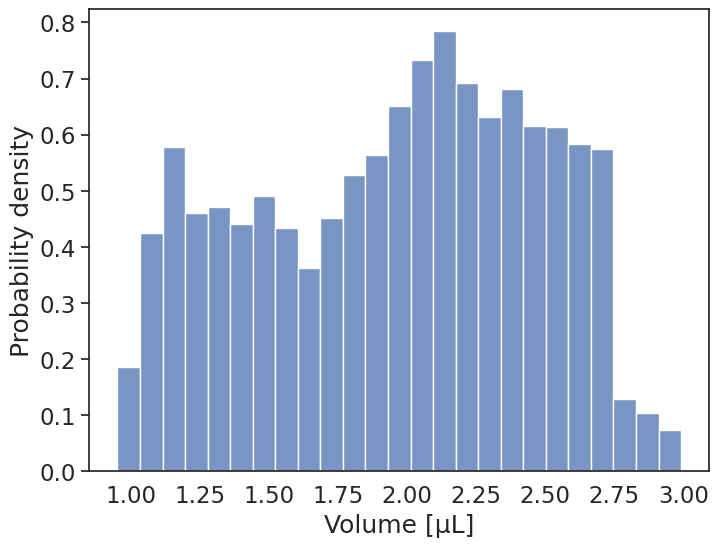

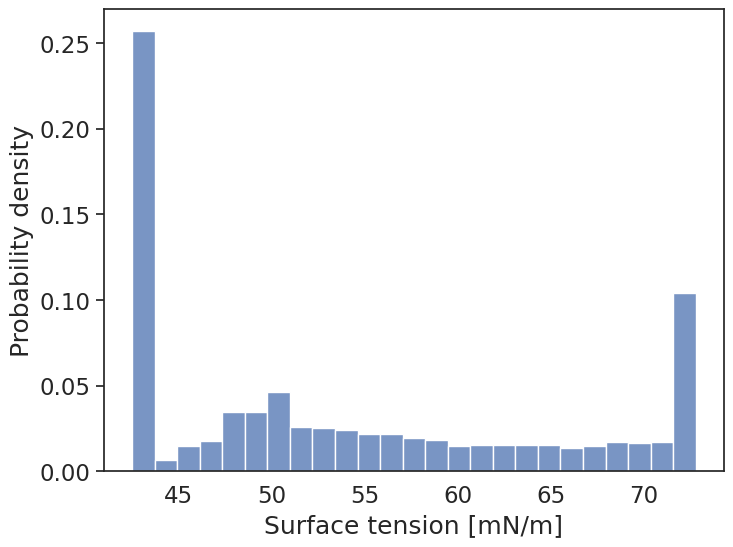

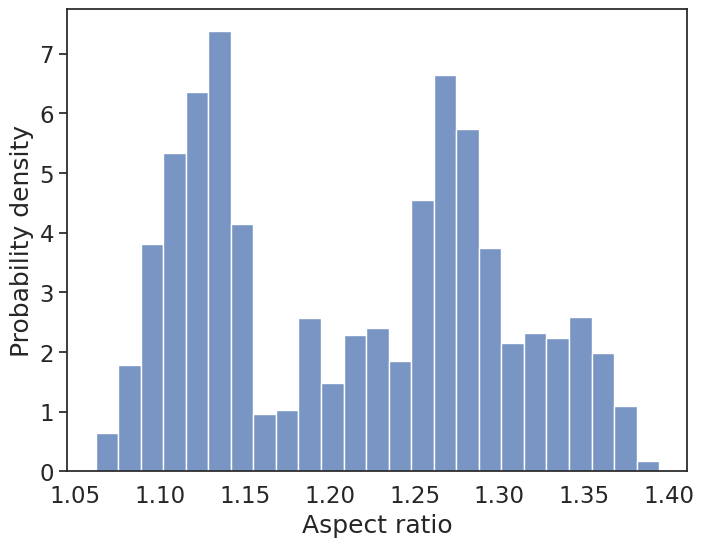

In [ ]:
path_annot =str('/content/drive/My Drive/Atieh_levitation/Annotated_data/')

annotated = sorted(os.listdir(path_annot))

df_list = []

for file in annotated[:6]:
  # if file.startswith('water'):
  #   temp_df = pd.read_csv(path_annot+file, sep=';')
  #   temp_df = temp_df.drop(columns=temp_df.columns[temp_df.columns.str.contains('^Unnamed')])
  #   df_list.append(temp_df)
  # else:
    temp_df = pd.read_csv(path_annot+file, sep=';')
    temp_df = temp_df.drop(columns=temp_df.columns[temp_df.columns.str.contains('^Unnamed')])
    df_list.append(temp_df)

annotated_df = pd.concat(df_list, ignore_index=True)

# annotated_df.tail()

plt.figure(figsize=(8,6))
plt.ylabel('Probability density')
sns.histplot(annotated_df.loc[:, 'Volume'], kde=False, bins=25, stat="density")
plt.xlabel('Volume [μL]')
plt.tick_params(bottom = False)

plt.figure(figsize=(8,6))
plt.ylabel('Probability density')
sns.histplot(annotated_df.loc[:, 'ST'], kde=False, bins=25, stat="density")
plt.xlabel('Surface tension [mN/m]')
plt.tick_params(bottom = False)

plt.figure(figsize=(8,6))
plt.ylabel('Probability density')
sns.histplot(1/annotated_df.loc[:, 'Aspect_Ratio'], kde=False, bins=25, stat="density")
plt.xlabel('Aspect ratio')
plt.tick_params(bottom = False)





In [ ]:

Time_new = annotated_df.pop('time')
Volume_new = annotated_df.pop('Volume')
AR_new = annotated_df.pop('Aspect_Ratio')
SA_new = annotated_df.pop('Integr_Surface_Area')
annotated_df.pop('conc')
content_new = annotated_df.pop('content')

annotated_df.tail()


,data_rho1,data_rho2,data_rho3,data_rho4,data_rho5,data_rho6,data_rho7,data_rho8,data_rho9,data_rho10,...,data_rho170,data_rho171,data_rho172,data_rho173,data_rho174,data_rho175,volt,current,centred_z,ST
4494,0.830085,0.831046,0.829743,0.829509,0.826976,0.825493,0.821641,0.818798,0.814599,0.810468,...,0.820515,0.822941,0.825641,0.828991,0.830160,0.830035,8,0.266,-1.715000,47.243544
4495,0.825082,0.826033,0.824712,0.824454,0.821892,0.820372,0.817013,0.813578,0.810676,0.806609,...,0.816147,0.817902,0.820624,0.824235,0.825247,0.825036,8,0.268,-1.728333,47.231916
4496,0.825276,0.826028,0.825585,0.824446,0.821881,0.820356,0.818448,0.814653,0.811666,0.807261,...,0.816229,0.818081,0.820632,0.824387,0.825847,0.825037,8,0.269,-1.683333,47.220288
4497,0.830089,0.829203,0.829769,0.826188,0.826606,0.823154,0.821713,0.817077,0.813570,0.809206,...,0.817827,0.819521,0.823170,0.826016,0.827491,0.830032,8,0.268,-1.668333,47.208660
4498,0.830051,0.830916,0.829518,0.829188,0.826560,0.824978,0.821031,0.818751,0.815971,0.811715,...,0.818390,0.822158,0.825957,0.826260,0.827628,0.830062,8,0.266,-1.685000,47.197033


In [ ]:
### Average z position of training dataset for a speicifc voltage:
# filtered_df = training_dataset.loc[training_dataset['volt'] == 8]
filtered_df = training_dataset[(training_dataset['volt'] >= 8) & (training_dataset['volt'] <= 11)]

target_avg_z = np.mean(filtered_df.centred_z)
print(target_avg_z)

0.06464680745005912


In [ ]:
### Center the Z-center

avg_z = np.average(annotated_df.centred_z)

annotated_df.centred_z = annotated_df.centred_z - avg_z + target_avg_z

print('Average z-centre: %.3f mm' %np.mean(annotated_df.centred_z))
annotated_df.tail()

Average z-centre: 0.065 mm


,data_rho1,data_rho2,data_rho3,data_rho4,data_rho5,data_rho6,data_rho7,data_rho8,data_rho9,data_rho10,...,data_rho170,data_rho171,data_rho172,data_rho173,data_rho174,data_rho175,volt,current,centred_z,ST
4494,0.830085,0.831046,0.829743,0.829509,0.826976,0.825493,0.821641,0.818798,0.814599,0.810468,...,0.820515,0.822941,0.825641,0.828991,0.830160,0.830035,8,0.266,0.083536,47.243544
4495,0.825082,0.826033,0.824712,0.824454,0.821892,0.820372,0.817013,0.813578,0.810676,0.806609,...,0.816147,0.817902,0.820624,0.824235,0.825247,0.825036,8,0.268,0.070203,47.231916
4496,0.825276,0.826028,0.825585,0.824446,0.821881,0.820356,0.818448,0.814653,0.811666,0.807261,...,0.816229,0.818081,0.820632,0.824387,0.825847,0.825037,8,0.269,0.115203,47.220288
4497,0.830089,0.829203,0.829769,0.826188,0.826606,0.823154,0.821713,0.817077,0.813570,0.809206,...,0.817827,0.819521,0.823170,0.826016,0.827491,0.830032,8,0.268,0.130203,47.208660
4498,0.830051,0.830916,0.829518,0.829188,0.826560,0.824978,0.821031,0.818751,0.815971,0.811715,...,0.818390,0.822158,0.825957,0.826260,0.827628,0.830062,8,0.266,0.113536,47.197033


### Scalling

In [ ]:
#Scalling training dataset

new_df_annot=MinMaxTransformTest(annotated_df, training_dataset, points=175)
new_df_annot.tail()


,data_rho1,data_rho2,data_rho3,data_rho4,data_rho5,data_rho6,data_rho7,data_rho8,data_rho9,data_rho10,...,data_rho166,data_rho167,data_rho168,data_rho169,data_rho170,data_rho171,data_rho172,data_rho173,data_rho174,data_rho175
4494,0.442292,0.443458,0.441877,0.441593,0.438520,0.436720,0.432046,0.428596,0.423502,0.418489,...,0.408206,0.413225,0.419732,0.424443,0.430679,0.433623,0.436900,0.440965,0.442384,0.442232
4495,0.436222,0.437375,0.435772,0.435460,0.432351,0.430506,0.426431,0.422262,0.418741,0.413806,...,0.403358,0.410054,0.414684,0.420529,0.425380,0.427509,0.430812,0.435193,0.436422,0.436166
4496,0.436457,0.437370,0.436831,0.435450,0.432337,0.430487,0.428172,0.423567,0.419942,0.414598,...,0.404462,0.409852,0.416282,0.420548,0.425480,0.427726,0.430822,0.435378,0.437150,0.436166
4497,0.442297,0.441222,0.441909,0.437564,0.438071,0.433882,0.432133,0.426508,0.422253,0.416957,...,0.405200,0.412009,0.416640,0.422483,0.427418,0.429474,0.433901,0.437355,0.439145,0.442228
4498,0.442251,0.443301,0.441604,0.441204,0.438015,0.436095,0.431306,0.428539,0.425166,0.420002,...,0.406698,0.413082,0.417919,0.423294,0.428102,0.432673,0.437283,0.437651,0.439311,0.442265



#### Normalize the rest of the features

In [ ]:
### Print the statistics of the training dataset
points=175
if training_dataset.shape[1]>2*points:
  stats = training_dataset.iloc[:, 2*points:].describe()
else:
  stats = training_dataset.iloc[:, points:].describe()


stats = stats.transpose()
stats


,count,mean,std,min,25%,50%,75%,max
volt,46695.0,8.063710,0.857414,6.600000,7.340000,7.970000,8.750000,10.000000
current,46695.0,0.312764,0.019648,0.272000,0.296000,0.312000,0.329000,0.366000
centred_z,46695.0,0.001997,0.094150,-0.323581,-0.069027,0.020304,0.080019,0.244943
ST,46695.0,49.504606,11.279460,29.024210,39.751155,49.820528,58.573276,69.925068


In [ ]:
def min_max_norm(x):
  return (x-stats['min'])/(stats['max']-stats['min'])

normed_annot_data_rest = min_max_norm(annotated_df.iloc[:, points:])


In [ ]:
#Putting scalled training dataset together

normed_annot_data = new_df_annot.copy()

normed_annot_data['centred_z'] = normed_annot_data_rest.centred_z
normed_annot_data['volt'] = normed_annot_data_rest.volt
normed_annot_data['current'] = normed_annot_data_rest.current
normed_annot_data['ST'] = normed_annot_data_rest.ST

normed_annot_data

,data_rho1,data_rho2,data_rho3,data_rho4,data_rho5,data_rho6,data_rho7,data_rho8,data_rho9,data_rho10,...,data_rho170,data_rho171,data_rho172,data_rho173,data_rho174,data_rho175,centred_z,volt,current,ST
0,0.498835,0.499759,0.498006,0.497628,0.495799,0.496750,0.492396,0.489260,0.487745,0.486767,...,0.488903,0.492265,0.494954,0.494926,0.496266,0.498970,0.590038,0.411765,-0.106383,1.070290
1,0.502916,0.504001,0.502416,0.502210,0.503229,0.500699,0.497538,0.494538,0.492864,0.488697,...,0.494186,0.495664,0.498491,0.499331,0.500093,0.502950,0.642806,0.411765,-0.106383,1.070290
2,0.500927,0.500562,0.500632,0.500525,0.497707,0.496240,0.496136,0.493226,0.491644,0.487124,...,0.491561,0.493160,0.496104,0.496330,0.497929,0.500894,0.672122,0.411765,-0.117021,1.070290
3,0.496881,0.498059,0.497616,0.496431,0.497683,0.496210,0.492851,0.493185,0.487363,0.485788,...,0.487472,0.493184,0.494437,0.496343,0.497936,0.496851,0.619353,0.411765,-0.117021,1.070290
4,0.496836,0.497867,0.496222,0.495944,0.497045,0.495423,0.492021,0.492091,0.487760,0.485664,...,0.488260,0.489730,0.492540,0.496348,0.498133,0.496901,0.648669,0.411765,-0.106383,1.070290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4494,0.442292,0.443458,0.441877,0.441593,0.438520,0.436720,0.432046,0.428596,0.423502,0.418489,...,0.430679,0.433623,0.436900,0.440965,0.442384,0.442232,0.716095,0.411765,-0.063830,0.445451
4495,0.436222,0.437375,0.435772,0.435460,0.432351,0.430506,0.426431,0.422262,0.418741,0.413806,...,0.425380,0.427509,0.430812,0.435193,0.436422,0.436166,0.692643,0.411765,-0.042553,0.445167
4496,0.436457,0.437370,0.436831,0.435450,0.432337,0.430487,0.428172,0.423567,0.419942,0.414598,...,0.425480,0.427726,0.430822,0.435378,0.437150,0.436166,0.771795,0.411765,-0.031915,0.444883
4497,0.442297,0.441222,0.441909,0.437564,0.438071,0.433882,0.432133,0.426508,0.422253,0.416957,...,0.427418,0.429474,0.433901,0.437355,0.439145,0.442228,0.798179,0.411765,-0.042553,0.444598


### Split the data into train and test

Now split the dataset into a training set and a test set.

We will use the test set in the final evaluation of our model.

In [ ]:
ST_saved = annotated_df.ST
# normed_test_data['ST'] = normed_test_data_rest.ST

new_train_data = normed_annot_data.sample(frac=0.8, random_state=0)
new_test_data = normed_annot_data.drop(new_train_data.index)


### Remove the surface tension from the datasets

In [ ]:
new_train_labels = new_train_data.pop('ST')
new_test_labels = new_test_data.pop('ST')

### Re-train NN

In [ ]:
example_batch = new_train_data[:10]
example_result = model.predict(example_batch)
example_result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step


array([[0.65449363],
       [0.91575456],
       [0.65336967],
       [0.653587  ],
       [0.87971807],
       [0.66957146],
       [0.6534164 ],
       [0.78560686],
       [0.8777592 ],
       [0.8796559 ]], dtype=float32)

In [ ]:
tf.data.experimental.enable_debug_mode()

# Recreate optimizer so it matches current model's variables
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='mean_squared_error',   # or your actual loss
    metrics=['mean_absolute_error', 'mean_squared_error']
)


In [ ]:
nan_indices = new_train_labels[new_train_labels.isna()].index.tolist()
len(nan_indices)

0

In [ ]:
# Display training progress by printing a single dot for each completed epoch
class PrintDot(keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs):
    if epoch % 100 == 0: print('')
    print('.', end='')

EPOCHS = 2000

# The patience parameter is the amount of epochs to check for improvement
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=50, min_delta=0, restore_best_weights=True)

history = model.fit(new_train_data, new_train_labels, epochs=EPOCHS,
                    validation_split = 0.2, verbose=0, callbacks=[early_stop, PrintDot()])



....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
......................................

### Training history and performance

Visualize the model's training progress using the stats stored in the `history` object.

In [ ]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mean_absolute_error,mean_squared_error,val_loss,val_mean_absolute_error,val_mean_squared_error,epoch
433,0.002399,0.024812,0.002399,0.002549,0.022605,0.002549,433
434,0.002163,0.022265,0.002163,0.003281,0.035509,0.003281,434
435,0.002181,0.022293,0.002181,0.002307,0.023416,0.002307,435
436,0.001963,0.020651,0.001963,0.001954,0.019622,0.001954,436
437,0.002032,0.020790,0.002032,0.002094,0.022907,0.002094,437


In [ ]:
# min_train_error=find_nearest(hist.mean_squared_error, min(hist.mean_squared_error))
# min_val_error=find_nearest(hist.val_mean_squared_error, min(hist.val_mean_squared_error))

# if min_val_error[1] > min_train_error[1]:
#   min_train_val_diff=find_nearest(hist.val_mean_squared_error[ min_train_error[1]: min_val_error[1]]-hist.mean_squared_error[ min_train_error[1]: min_val_error[1]], min(abs(hist.val_mean_squared_error[ min_train_error[1]: min_val_error[1]]-hist.mean_squared_error[ min_train_error[1]: min_val_error[1]])))
# elif min_val_error[1] < min_train_error[1]:
#   min_train_val_diff=find_nearest(hist.val_mean_squared_error[ min_val_error[1]: min_train_error[1]]-hist.mean_squared_error[ min_val_error[1]: min_train_error[1]], min(abs(hist.val_mean_squared_error[ min_val_error[1]: min_train_error[1]]-hist.mean_squared_error[ min_val_error[1]: min_train_error[1]])))
# else:
#   min_train_val_diff=min_val_error


# print('Min train MSE: %.8f, index: %d' %(min_train_error[0], min_train_error[1]))

# print('Min val MSE: %.8f, index: %d' %(min_val_error[0], min_val_error[1]))

# print('Diff train-val MSE at min val MSE %.8f: '%(hist.mean_squared_error[min_val_error[1]] - min_val_error[0]))

# if min_val_error[1] > min_train_error[1]:
#   idx=min_train_error[1] + min_train_val_diff[1]
#   print('Min diff train-val MSE: %.8f, index: %d, train MSE: %.8f' %(min_train_val_diff[0],  idx, hist.mean_squared_error[idx]))
# elif min_val_error[1] < min_train_error[1]:
#   idx=min_val_error[1] + min_train_val_diff[1]
#   print('Min diff train-val MSE: %.8f, index: %d, train MSE: %.8f' %(min_train_val_diff[0],  idx, hist.mean_squared_error[idx]))
# else:
#   print('Min diff train-val MSE: %.8f, index: %d' %(min_train_val_diff[0],  min_val_error[1] + min_train_val_diff[1]))




In [ ]:
## Re-scale target feature
def rescaling(target, min=stats.loc['ST']['min'], max=stats.loc['ST']['max']):
  target=np.asarray(target)
  return (max-min)*(target)+min

test_predictions = model.predict(new_test_data).flatten()
train_predictions = model.predict(new_train_data).flatten()

ST_real_test=rescaling(new_test_labels)
ST_pred_test=rescaling(test_predictions)

ST_real_train=rescaling(new_train_labels)
ST_pred_train=rescaling(train_predictions)

#Re-scalling check:
# plt.figure(figsize=(8,6))
# plt.scatter(range(len(test_labels)), test_labels)
# plt.ylabel('Normalizaed surface tension')
# plt.xlabel('Instances')

# plt.figure(figsize=(8,6))
# plt.scatter(range(len(ST_real_test)), ST_real_test)
# plt.ylabel('Surface tension (mN/m)')
# plt.xlabel('Instances')

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


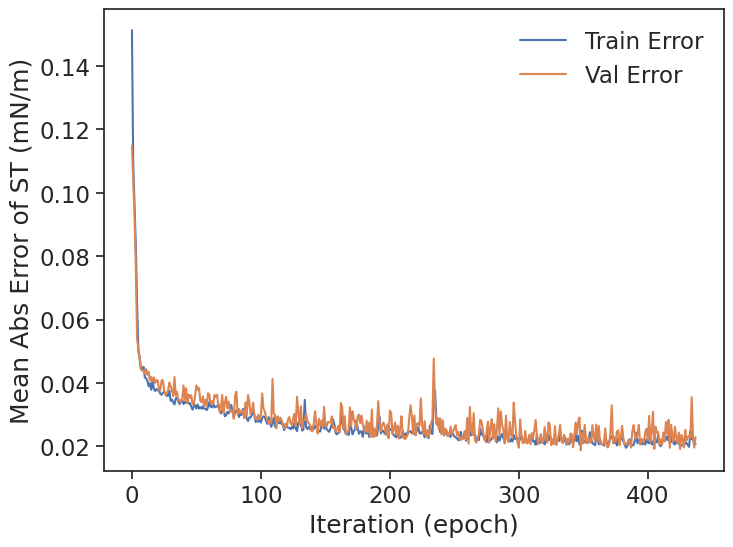

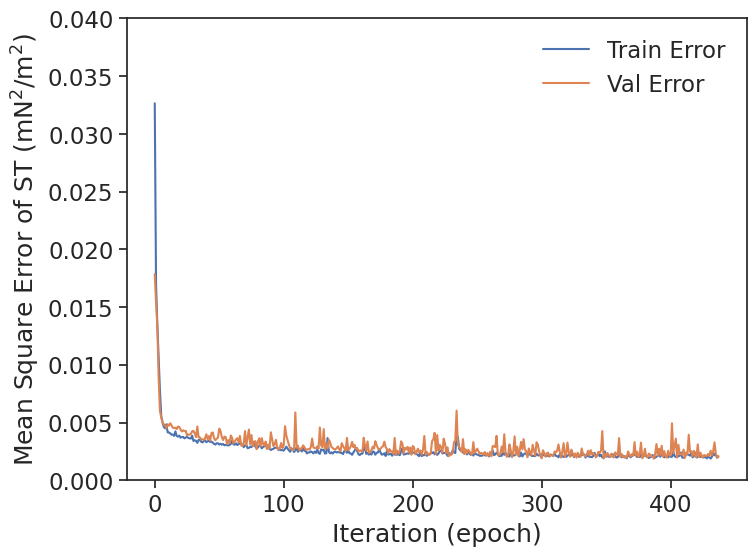

In [ ]:
def plot_history(history, savefig=True, path=''):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  sns.set_theme(style='ticks', font_scale=1.5)

  plt.figure(figsize=(8,6))
  plt.xlabel('Iteration (epoch)')
  plt.ylabel('Mean Abs Error of ST (mN/m)')
  plt.plot(hist['epoch'], hist['mean_absolute_error'],
           label='Train Error')
  plt.plot(hist['epoch'], hist['val_mean_absolute_error'],
           label = 'Val Error')
  # plt.ylim([0,0.2])
  plt.legend(frameon=False)
  if savefig==True:
    plt.savefig(path+'training_outcome_MAE_svg', dpi=300, format='svg')
    plt.savefig(path+'training_outcome_MAE_png', dpi=300, format='png')


  plt.figure(figsize=(8,6))
  plt.xlabel('Iteration (epoch)')
  plt.ylabel('Mean Square Error of ST (mN$^2$/m$^2$)')
  plt.plot(hist['epoch'], hist['mean_squared_error'],
           label='Train Error')
  plt.plot(hist['epoch'], hist['val_mean_squared_error'],
           label = 'Val Error')
  plt.ylim([0,0.04])
  plt.legend(frameon=False)
  if savefig==True:
    plt.savefig(path+'training_outcome_MSE_svg', dpi=300, format='svg')
    plt.savefig(path+'training_outcome_MSE_png', dpi=300, format='png')

path='/content/drive/My Drive/DropLev/for_draft/Experimental/Figures/'

plot_history(history, savefig=False, path=path)

The graph shows that on the validation set, the average error is usually around +/- 2 MPG. Is this good? We'll leave that decision up to you.

Let's see how well the model generalizes by using the **test** set, which we did not use when training the model.  This tells us how well we can expect the model to predict when we use it in the real world.

### Make predictions

Finally, predict ST values using data in the testing set:

In [ ]:
def density_scatter(x, y, title=None, label=None, colours='magma_r', lim1=10, lim2=80, eq_sq=True, figsize=(8,8)):
  # Calculate the point density
  x=np.asarray(x)
  y=np.asarray(y)
  xy = np.vstack([x, y])
  z = gaussian_kde(xy)(xy)
  # Sort the points by density, so that the densest points are plotted last
  idx = z.argsort()
  x, y, z = x[idx], y[idx], z[idx]

  fig, ax = plt.subplots(figsize=figsize)
  ax.set_facecolor('whitesmoke')
  if title!=None:
    plt.title(title)
  im=ax.scatter(x, y, label=label, c=z, s=50, cmap=colours)
  plt.xlabel('True Values of ST (mN/m)')
  plt.ylabel('Predictions of ST (mN/m)')
  if eq_sq==True:
    plt.axis('equal')
    plt.axis('square')
  # plt.xlim([lim1, lim2])
  # plt.ylim([lim1, lim2])
  norm = Normalize(vmin = np.min(z), vmax = np.max(z))
  cbar = fig.colorbar(cm.ScalarMappable(norm = norm, cmap=colours), ax=ax)
  cbar.ax.set_ylabel('Density')


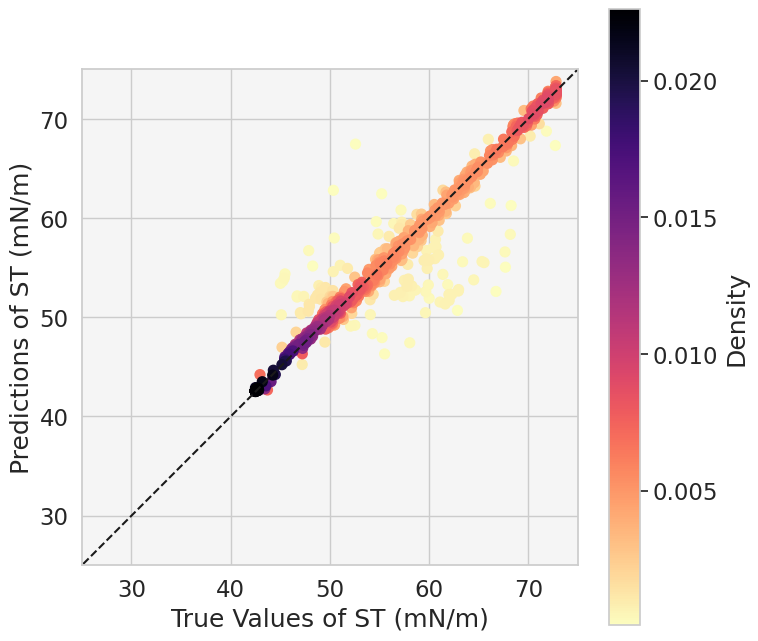

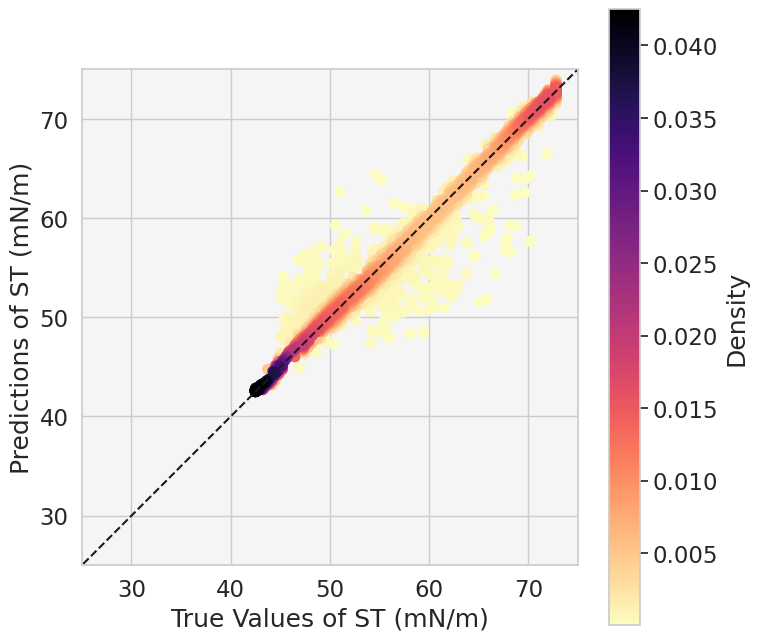

In [ ]:

savefig=False

sns.set_theme(style='whitegrid', font_scale=1.5, color_codes=False)

colours='magma_r'


density_scatter(ST_real_test, ST_pred_test, colours=colours)
_ = plt.plot([-100, 100], [-100, 100], '--k')
plt.xlim(25, 75)
plt.ylim(25, 75)
if savefig==True:
  plt.savefig(path+'test_data_error_plot_svg', dpi=300, format='svg')
  plt.savefig(path+'test_data_error_plot_png', dpi=300, format='png')


density_scatter(ST_real_train, ST_pred_train, colours=colours)
_ = plt.plot([-100, 100], [-100, 100], '--k')
plt.xlim(25, 75)
plt.ylim(25, 75)
if savefig==True:
  plt.savefig(path+'training_data_error_plot_svg', dpi=300, format='svg')
  plt.savefig(path+'training_data_error_plot_png', dpi=300, format='png')




Error distribution

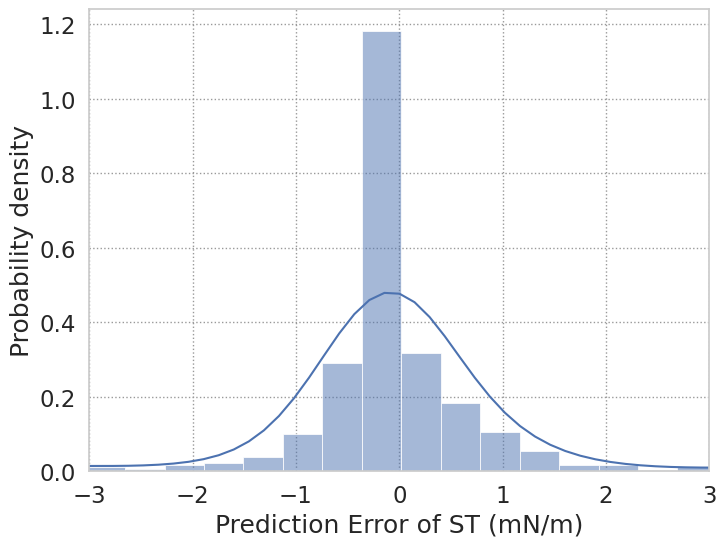

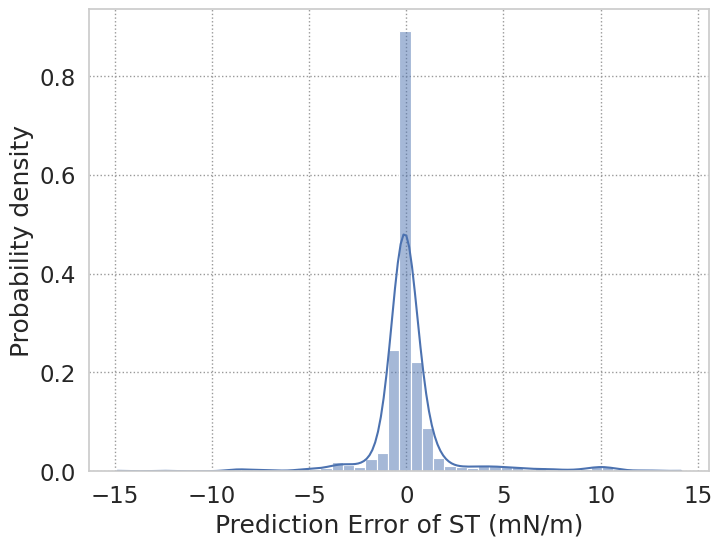

In [ ]:
error_test = ST_real_test - ST_pred_test

sns.set_theme(style='whitegrid', font_scale=1.5)
sns.set_style("whitegrid", {"grid.color": ".6", "grid.linestyle": ":"})
savefig=False

plt.figure(figsize=(8,6))
sns.histplot(error_test, bins = 76, kde=True, stat="density")
plt.xlabel("Prediction Error of ST (mN/m)")
_ = plt.ylabel("Probability density")
plt.xlim(-3, 3)
plt.tick_params(bottom = False)
if savefig==True:
  plt.savefig(path+'test_data_error_distr_lim_svg', dpi=300, format='svg')
  plt.savefig(path+'test_data_error_distr_lim_png', dpi=300, format='png')

plt.figure(figsize=(8,6))
sns.histplot(error_test, bins = 50, kde=True, stat="density")
plt.xlabel("Prediction Error of ST (mN/m)")
_ = plt.ylabel("Probability density")
plt.tick_params(bottom = False)
if savefig==True:
  plt.savefig(path+'test_data_error_distr_svg', dpi=300, format='svg')
  plt.savefig(path+'test_data_error_distr_png', dpi=300, format='png')



## Visualize the predictions

### Remove the surface tension from the datasets

In [ ]:
train_labels = training_dataset.pop('ST')
# test_labels = normed_test_data.pop('ST')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


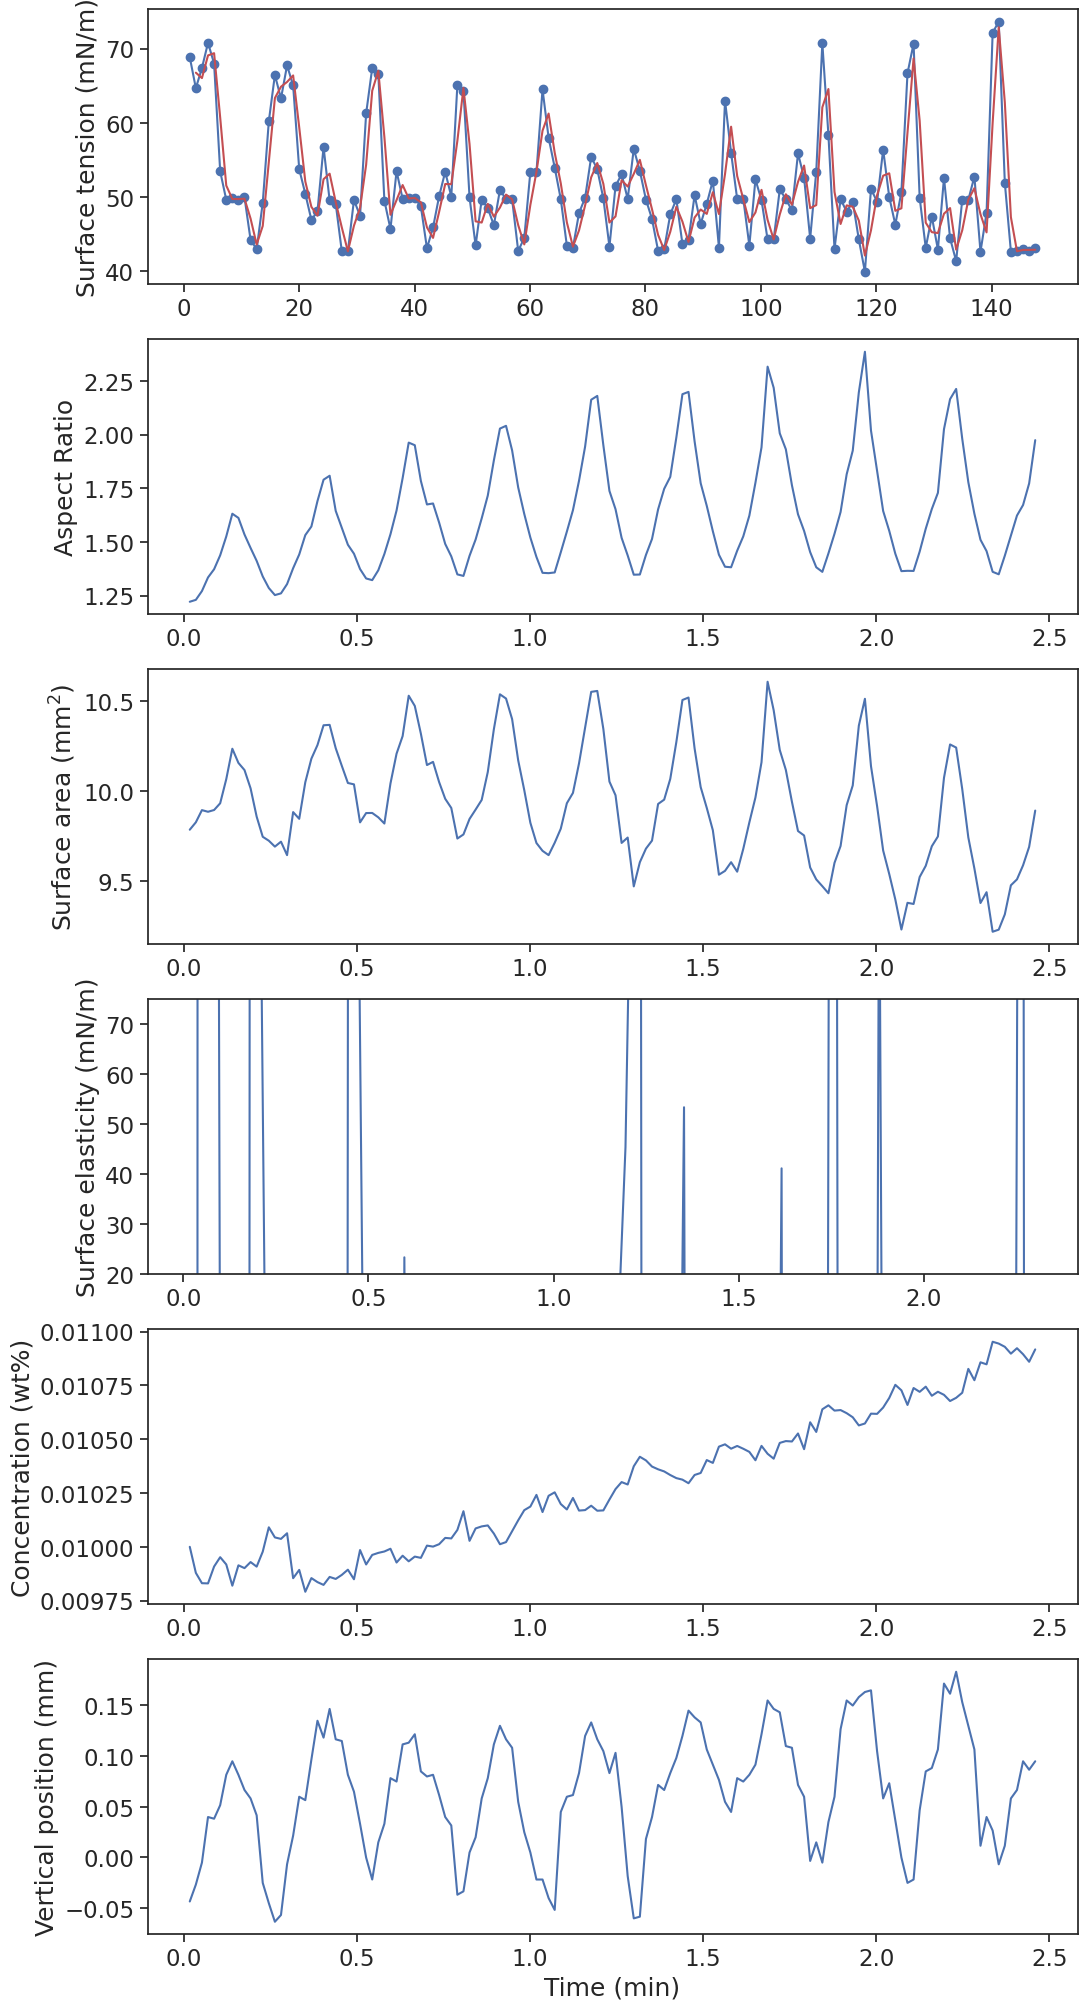

In [ ]:
## Re-scale target feature
def rescaling(target, min=stats.loc['ST']['min'], max=stats.loc['ST']['max']):
  target=np.asarray(target)
  return (max-min)*(target)+min

test_predictions = model.predict(normed_test_data).flatten()
# train_predictions = model.predict(normed_train_data).flatten()

# ST_real_test=rescaling(test_labels)
ST_pred_test=rescaling(test_predictions)

ST_real_train=rescaling(train_labels)
# ST_pred_train=rescaling(train_predictions)

ST_series = pd.Series(ST_pred_test)
ST_moving_avg = ST_series.rolling(window=2).mean()


fig, axs = plt.subplots(6, figsize=(12, 25))
axs[0].plot(Time, ST_pred_test, '-o')
axs[0].plot(Time, ST_moving_avg, '-r')
axs[0].set_ylabel('Surface tension (mN/m)')
# axs[0].set_ylim(50,75)
axs[1].plot(Time/60, 1/Aspect_Ratio_test)
axs[1].set_ylabel('Aspect Ratio')
axs[2].plot(Time/60, SA)
axs[2].set_ylabel('Surface area (mm$^2$)')
axs[3].plot(Time/60, concentration)
axs[3].set_ylabel('Concentration (wt%)')
axs[4].plot(Time/60, test_dataset.centred_z)
axs[4].set_ylabel('Vertical position (mm)')
axs[4].set_xlabel('Time (min)')

plt.savefig(path_files+'Processed_with_predicted_ST/after_retraining/Figures/'+folder+folder.split('/')[0]+'_'+filename.split('.csv')[0]+'.svg')
plt.savefig(path_files+'Processed_with_predicted_ST/after_retraining/Figures/'+folder+folder.split('/')[0]+'_'+filename.split('.csv')[0]+'.png')






### Save the processed data with the predicted ST

In [ ]:

test_dataset['surface_area'] = Surface_Area
test_dataset['volume'] = volume_test
test_dataset['AR'] = Aspect_Ratio_test
test_dataset['Time'] = Time
test_dataset['content'] = concentration
test_dataset['ST_pred'] = ST_pred_test

test_dataset.to_csv(path_files+'/Processed_with_predicted_ST/after_retraining/Data/'+folder+folder.split('/')[0]+'_'+filename)
test_dataset.tail()


,data_rho1,data_rho2,data_rho3,data_rho4,data_rho5,data_rho6,data_rho7,data_rho8,data_rho9,data_rho10,...,data_rho175,volt,current,centred_z,surface_area,volume,AR,Time,content,ST_pred
135,0.958408,0.956117,0.955060,0.951880,0.946534,0.942319,0.934480,0.927172,0.917956,0.909222,...,0.958390,10.0,0.314,0.058206,9.476551,2.426923,0.653913,143.322428,0.010898,42.625029
136,0.973411,0.974481,0.973473,0.967010,0.963341,0.956420,0.947952,0.938940,0.925863,0.914445,...,0.973390,9.5,0.304,0.066540,9.509562,2.421319,0.616041,144.376374,0.010923,42.694715
137,0.983410,0.987824,0.986647,0.980425,0.975225,0.969294,0.960831,0.949631,0.937915,0.923663,...,0.983391,9.0,0.292,0.094873,9.587790,2.427521,0.597973,145.430357,0.010895,42.997113
138,1.001746,0.999506,0.998557,0.992183,0.987045,0.977784,0.966350,0.953927,0.940550,0.924365,...,0.999348,8.5,0.281,0.086540,9.690403,2.435362,0.564060,146.484283,0.010860,42.700311
139,1.033357,1.030940,1.026508,1.020029,1.011452,0.998730,0.984280,0.968013,0.951447,0.928847,...,1.030140,8.0,0.270,0.094873,9.892359,2.422540,0.506452,147.538388,0.010917,43.047435


In [ ]:

model.save(path_files+'/Processed_with_predicted_ST/after_retraining/Models/Atiehs_model.h5')

